In [40]:
import math
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [41]:
class QuadState(TypedDict) :
    a : int
    b : int
    c : int
    equation: str
    d : float
    result: str

In [42]:
graph = StateGraph(QuadState)

In [43]:
def show_equation(state : QuadState):
    equation = f"{state['a']}x2{state['b']}x{state['c']}"

    return {'equation' : equation}

def get_discriminant(state:QuadState):
    d = (state['b'] ** 2 - 4 * state['a'] * state['c'])

    return {'d' : d}

def real_root(state : QuadState):
    r1 = (-state['b'] - math.sqrt(state['d'])) / 2 * state['a']
    r2 = (-state['b'] + math.sqrt(state['d'])) / 2 * state['a']

    result = f"the 2 real roots are {r1} and {r2}"

    return {'result' : result}

def repeated_root(state : QuadState):
    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_root(state:QuadState):
    result = "No Real Roots exist"

    return {'result' : result}

def check_condition(state: QuadState) -> Literal['real_root','repeated_root','no_real_root']:
    d = state['d']

    if d > 0 :
        return 'real_root'
    elif d == 0 :
        return 'repeated_root'
    else :
        return 'no_real_root'

In [44]:
graph.add_node('show_equation',show_equation)
graph.add_node('get_discriminant',get_discriminant)
graph.add_node('real_root',real_root)
graph.add_node('repeated_root' , repeated_root)
graph.add_node('no_real_root',no_real_root)

In [45]:
graph.add_edge(START , 'show_equation')
graph.add_edge('show_equation','get_discriminant')
graph.add_conditional_edges('get_discriminant',check_condition)
graph.add_edge('real_root',END)
graph.add_edge('no_real_root',END)
graph.add_edge('repeated_root',END)

In [46]:
workflow = graph.compile()

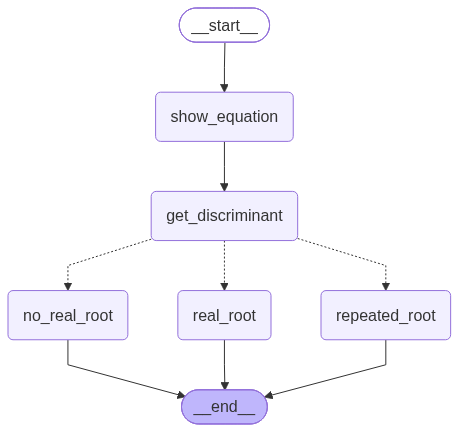

In [47]:
workflow

In [50]:
initial_state = {'a' : 5 ,'b':-6,'c':-1}

workflow.invoke(initial_state)

{'a': 5,
 'b': -6,
 'c': -1,
 'equation': '5x2-6x-1',
 'd': 56,
 'result': 'the 2 real roots are -3.7082869338697066 and 33.7082869338697'}